## Import Necessary Libraries

In [22]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print("All libraries imported successfully.")

Using device: cpu
All libraries imported successfully.


## CONFIGURATION & HYPERPARAMETERS

In [23]:
EPISODES = 200000
TEST_EPISODES = 1000

ALPHA = 0.1
GAMMA = 0.99

EPSILON = 1.0
EPSILON_DECAY = 0.999985
EPSILON_MIN = 0.01

START_TIME = 0
MAX_TIME = 480

CHARGING_TIME = 40
WAITING_TIME = 20
SERVICE_TIME = 5

NUM_TASKS = 8
NUM_CHARGERS = 2
TOTAL_NODES = NUM_TASKS + NUM_CHARGERS + 1

# recalibrated for 8-task experiment
MEAN_TRAVEL_TIME = 44.0
MEAN_BATT_PER_EDGE = 18.75

PROB_CHARGER_FULL = 0.35

TASK_REWARD = 150
PENALTY_UNFINISHED_TASK = -120
PENALTY_DEAD_BATTERY = -500
PENALTY_TIME_EXCEEDED = -500
INVALID_ACTION_PENALTY = -100


print("Expected total travel time:", NUM_TASKS * MEAN_TRAVEL_TIME)
print("Expected total service time:", NUM_TASKS * SERVICE_TIME)
print("Expected total battery demand:", NUM_TASKS * MEAN_BATT_PER_EDGE)
print("Expected total day with one charge:", NUM_TASKS * MEAN_TRAVEL_TIME + NUM_TASKS * SERVICE_TIME + CHARGING_TIME)

Expected total travel time: 352.0
Expected total service time: 40
Expected total battery demand: 150.0
Expected total day with one charge: 432.0


In [24]:
# ============================================================
# ENVIRONMENT
# ============================================================

class EVEnvironment(gym.Env):

    def __init__(self):
        super().__init__()

        self.wait_action = NUM_TASKS + NUM_CHARGERS
        self.action_space = spaces.Discrete(NUM_TASKS + NUM_CHARGERS + 1)

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(4 + NUM_TASKS,),
            dtype=np.float32
        )

    # --------------------------------------------------------

    def reset(self, seed=None, options=None):
        self.current_time = START_TIME
        self.current_location = 0
        self.battery_level = 100.0
        self.tasks_done = np.zeros(NUM_TASKS)
        self.charge_visits = 0
        self.pending_full_station = False
        self.pending_station_idx = -1
        return self._get_obs(), {}

    # --------------------------------------------------------

    def _get_obs(self):
        return np.concatenate([
            [self.current_time / MAX_TIME],
            [self.current_location / TOTAL_NODES],
            [self.battery_level / 100.0],
            [1.0 if self.pending_full_station else 0.0],
            self.tasks_done
        ]).astype(np.float32)

    # --------------------------------------------------------

    def get_valid_actions(self):
        valid_actions = []

        # If a station was found full, agent can WAIT or go somewhere else
        if self.pending_full_station:
            valid_actions.append(self.wait_action)

            for i in range(NUM_TASKS):
                if self.tasks_done[i] == 0:
                    valid_actions.append(i)

            for c in range(NUM_CHARGERS):
                if c != self.pending_station_idx:
                    valid_actions.append(NUM_TASKS + c)

            return valid_actions

        # Normal case: unfinished tasks + all chargers
        for i in range(NUM_TASKS):
            if self.tasks_done[i] == 0:
                valid_actions.append(i)

        for c in range(NUM_CHARGERS):
            valid_actions.append(NUM_TASKS + c)

        return valid_actions

    # --------------------------------------------------------

    def step(self, action):
        reward = 0.0
        done = False

        valid_actions = self.get_valid_actions()

        if action not in valid_actions:
            reward = INVALID_ACTION_PENALTY
            return self._get_obs(), reward, done, False, {}

        # ====================================================
        # WAIT ACTION
        # ====================================================
        if action == self.wait_action:
            if not self.pending_full_station:
                reward = INVALID_ACTION_PENALTY
                return self._get_obs(), reward, done, False, {}

            if self.current_time + WAITING_TIME + CHARGING_TIME > MAX_TIME:
                self.current_time = MAX_TIME
                reward = PENALTY_TIME_EXCEEDED
                done = True
                return self._get_obs(), reward, done, False, {}

            self.current_time += WAITING_TIME
            reward -= WAITING_TIME

            self.current_time += CHARGING_TIME
            reward -= CHARGING_TIME

            self.battery_level = 100.0
            self.charge_visits += 1
            self.pending_full_station = False
            self.pending_station_idx = -1

            return self._get_obs(), reward, done, False, {}

        # ====================================================
        # STOCHASTIC TRAVEL
        # ====================================================
        noise = random.uniform(0.9, 1.1)
        travel_time = MEAN_TRAVEL_TIME * noise
        battery_used = MEAN_BATT_PER_EDGE * noise

        extra_service = SERVICE_TIME if action < NUM_TASKS else 0

        if self.current_time + travel_time + extra_service > MAX_TIME:
            self.current_time = MAX_TIME
            reward = PENALTY_TIME_EXCEEDED
            done = True
            return self._get_obs(), reward, done, False, {}

        if self.battery_level - battery_used <= 0:
            self.battery_level = 0.0
            reward = PENALTY_DEAD_BATTERY
            done = True
            return self._get_obs(), reward, done, False, {}

        self.current_time += travel_time
        self.battery_level -= battery_used
        reward -= travel_time

        # ====================================================
        # TASK ACTION
        # ====================================================
        if action < NUM_TASKS:
            self.current_time += SERVICE_TIME
            reward -= SERVICE_TIME

            self.tasks_done[action] = 1
            reward += TASK_REWARD
            self.current_location = action + 1

        # ====================================================
        # CHARGER ACTION
        # ====================================================
        else:
            charger_idx = action - NUM_TASKS
            self.current_location = action + 1

            if random.random() < PROB_CHARGER_FULL:
                self.pending_full_station = True
                self.pending_station_idx = charger_idx
                return self._get_obs(), reward, done, False, {}

            if self.current_time + CHARGING_TIME > MAX_TIME:
                self.current_time = MAX_TIME
                reward = PENALTY_TIME_EXCEEDED
                done = True
                return self._get_obs(), reward, done, False, {}

            self.current_time += CHARGING_TIME
            reward -= CHARGING_TIME
            self.battery_level = 100.0
            self.charge_visits += 1
            self.pending_full_station = False
            self.pending_station_idx = -1

        if np.all(self.tasks_done):
            done = True

        if done:
            unfinished = NUM_TASKS - np.sum(self.tasks_done)
            reward += PENALTY_UNFINISHED_TASK * unfinished

        self.current_time = min(self.current_time, MAX_TIME)
        self.battery_level = max(0.0, self.battery_level)

        return self._get_obs(), reward, done, False, {}

In [25]:
def heuristic_policy(env):
    valid_actions = env.get_valid_actions()

    # if charger was full, either wait or go elsewhere
    if env.pending_full_station:
        if env.battery_level <= 35 and env.wait_action in valid_actions:
            return env.wait_action

        for a in valid_actions:
            if a < NUM_TASKS:
                return a

        for a in valid_actions:
            if NUM_TASKS <= a < NUM_TASKS + NUM_CHARGERS:
                return a

    # normal case
    if env.battery_level <= 35:
        for a in valid_actions:
            if NUM_TASKS <= a < NUM_TASKS + NUM_CHARGERS:
                return a

    for a in valid_actions:
        if a < NUM_TASKS:
            return a

    return valid_actions[0]

In [26]:
def discretize(state):
    return tuple((state * 10).astype(int))

In [27]:
def train_q_learning(env):
    q_table = {}
    epsilon = EPSILON

    for ep in range(EPISODES):
        state, _ = env.reset()
        state = discretize(state)
        done = False

        while not done:
            valid_actions = env.get_valid_actions()

            if random.random() < epsilon:
                action = random.choice(valid_actions)
            else:
                q_values = q_table.get(state, np.zeros(env.action_space.n))
                masked_q = np.full(env.action_space.n, -np.inf)
                masked_q[valid_actions] = q_values[valid_actions]
                action = int(np.argmax(masked_q))

            next_state, reward, done, _, _ = env.step(action)
            next_state = discretize(next_state)

            q_old = q_table.get(state, np.zeros(env.action_space.n))[action]
            q_next = np.max(q_table.get(next_state, np.zeros(env.action_space.n)))

            q_new = q_old + ALPHA * (reward + GAMMA * q_next - q_old)
            q_table.setdefault(state, np.zeros(env.action_space.n))[action] = q_new

            state = next_state

        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    return q_table

In [28]:
def train_sarsa(env):
    q_table = {}
    epsilon = EPSILON

    for ep in range(EPISODES):
        state, _ = env.reset()
        state = discretize(state)

        valid_actions = env.get_valid_actions()
        if random.random() < epsilon:
            action = random.choice(valid_actions)
        else:
            q_values = q_table.get(state, np.zeros(env.action_space.n))
            masked_q = np.full(env.action_space.n, -np.inf)
            masked_q[valid_actions] = q_values[valid_actions]
            action = int(np.argmax(masked_q))

        done = False

        while not done:
            next_state, reward, done, _, _ = env.step(action)
            next_state = discretize(next_state)

            next_valid_actions = env.get_valid_actions()

            if random.random() < epsilon:
                next_action = random.choice(next_valid_actions)
            else:
                q_values = q_table.get(next_state, np.zeros(env.action_space.n))
                masked_q = np.full(env.action_space.n, -np.inf)
                masked_q[next_valid_actions] = q_values[next_valid_actions]
                next_action = int(np.argmax(masked_q))

            q_old = q_table.get(state, np.zeros(env.action_space.n))[action]
            q_next = q_table.get(next_state, np.zeros(env.action_space.n))[next_action]

            q_new = q_old + ALPHA * (reward + GAMMA * q_next - q_old)
            q_table.setdefault(state, np.zeros(env.action_space.n))[action] = q_new

            state = next_state
            action = next_action

        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    return q_table

In [29]:
class DQN(nn.Module):

    def __init__(self, s, a):
        super().__init__()
        self.fc1 = nn.Linear(s, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, a)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [30]:
class Agent:

    def __init__(self, s, a, double=False):
        self.model = DQN(s, a).to(device)
        self.target = DQN(s, a).to(device)
        self.target.load_state_dict(self.model.state_dict())
        self.opt = optim.Adam(self.model.parameters(), lr=0.0005)
        self.mem = deque(maxlen=50000)
        self.gamma = GAMMA
        self.epsilon = EPSILON
        self.double = double
        self.train_steps = 0

    def act(self, state, valid_actions, greedy=False):
        if (not greedy) and random.random() < self.epsilon:
            return random.choice(valid_actions)

        s = torch.FloatTensor(state).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.model(s).cpu().numpy().flatten()

        masked_q = np.full(len(q_values), -np.inf)
        masked_q[valid_actions] = q_values[valid_actions]

        return int(np.argmax(masked_q))

    def train(self):
        if len(self.mem) < 64:
            return

        batch = random.sample(self.mem, 64)
        s, a, r, ns, d, next_valids = zip(*batch)

        s = torch.FloatTensor(np.array(s)).to(device)
        ns = torch.FloatTensor(np.array(ns)).to(device)
        a = torch.LongTensor(a).to(device)
        r = torch.FloatTensor(r).to(device)
        d = torch.FloatTensor(d).to(device)

        q = self.model(s).gather(1, a.unsqueeze(1)).squeeze()

        with torch.no_grad():
            target_q_values = self.target(ns).cpu().numpy()
            online_q_values = self.model(ns).cpu().numpy()

            masked_next_q = np.full((len(batch), self.model.fc3.out_features), -np.inf)

            for i, valid_actions in enumerate(next_valids):
                masked_next_q[i, valid_actions] = target_q_values[i, valid_actions]

            if self.double:
                masked_online_q = np.full((len(batch), self.model.fc3.out_features), -np.inf)
                for i, valid_actions in enumerate(next_valids):
                    masked_online_q[i, valid_actions] = online_q_values[i, valid_actions]

                next_actions = np.argmax(masked_online_q, axis=1)
                next_q = masked_next_q[np.arange(len(batch)), next_actions]
            else:
                next_q = np.max(masked_next_q, axis=1)

            next_q = torch.FloatTensor(next_q).to(device)
            target = r + (1 - d) * self.gamma * next_q

        loss = F.mse_loss(q, target)

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        self.train_steps += 1
        if self.train_steps % 500 == 0:
            self.target.load_state_dict(self.model.state_dict())

        self.epsilon = max(EPSILON_MIN, self.epsilon * EPSILON_DECAY)

In [31]:
def test(env, policy_fn):

    data = []

    for _ in range(TEST_EPISODES):
        s, _ = env.reset()
        done = False

        while not done:
            a = policy_fn(env, s)
            s, _, done, _, _ = env.step(a)

        completed_tasks = int(np.sum(env.tasks_done))
        remaining_tasks = NUM_TASKS - completed_tasks

        data.append([
            env.current_time,
            completed_tasks,
            remaining_tasks,
            completed_tasks / NUM_TASKS,
            env.charge_visits,
            max(0.0, env.battery_level)
        ])

    return pd.DataFrame(
        data,
        columns=[
            "TotalTimeMin",
            "CompletedTasks",
            "RemainingTasks",
            "TaskCompletionRate",
            "ChargeVisits",
            "FinalBatteryPct"
        ]
    )

In [32]:
env = EVEnvironment()

print("Training Q-Learning...")
q_table = train_q_learning(env)

print("Training SARSA...")
sarsa_table = train_sarsa(env)

print("Training DQN...")
agent_dqn = Agent(
    env.observation_space.shape[0],
    env.action_space.n
)

for _ in range(EPISODES):
    s, _ = env.reset()
    done = False

    while not done:
        valid_actions = env.get_valid_actions()
        a = agent_dqn.act(s, valid_actions, greedy=False)
        ns, r, done, _, _ = env.step(a)
        next_valid_actions = env.get_valid_actions()
        agent_dqn.mem.append((s, a, r, ns, done, next_valid_actions))
        agent_dqn.train()
        s = ns

print("Training Double DQN...")
agent_ddqn = Agent(
    env.observation_space.shape[0],
    env.action_space.n,
    double=True
)

for _ in range(EPISODES):
    s, _ = env.reset()
    done = False

    while not done:
        valid_actions = env.get_valid_actions()
        a = agent_ddqn.act(s, valid_actions, greedy=False)
        ns, r, done, _, _ = env.step(a)
        next_valid_actions = env.get_valid_actions()
        agent_ddqn.mem.append((s, a, r, ns, done, next_valid_actions))
        agent_ddqn.train()
        s = ns

Training Q-Learning...
Training SARSA...
Training DQN...
Training Double DQN...


In [33]:
results = {

    "Heuristic": test(
        env,
        lambda e, s: heuristic_policy(e)
    ),

    "Q-Learning": test(
        env,
        lambda e, s: int(
            np.argmax(
                np.where(
                    np.isin(np.arange(env.action_space.n), e.get_valid_actions()),
                    q_table.get(discretize(s), np.zeros(env.action_space.n)),
                    -np.inf
                )
            )
        )
    ),

    "SARSA": test(
        env,
        lambda e, s: int(
            np.argmax(
                np.where(
                    np.isin(np.arange(env.action_space.n), e.get_valid_actions()),
                    sarsa_table.get(discretize(s), np.zeros(env.action_space.n)),
                    -np.inf
                )
            )
        )
    ),

    "DQN": test(
        env,
        lambda e, s: agent_dqn.act(s, e.get_valid_actions(), greedy=True)
    ),

    "DoubleDQN": test(
        env,
        lambda e, s: agent_ddqn.act(s, e.get_valid_actions(), greedy=True)
    )
}

In [34]:
for k, v in results.items():
    v.to_csv(f"{k}.csv", index=False)

In [35]:
summary = []

for model_name, df in results.items():

    stats = {
        "Model": model_name,

        "Avg Time": df["TotalTimeMin"].mean(),
        "Std Time": df["TotalTimeMin"].std(),
        "Min Time": df["TotalTimeMin"].min(),
        "Max Time": df["TotalTimeMin"].max(),

        "Avg Completed Tasks": df["CompletedTasks"].mean(),
        "Std Completed Tasks": df["CompletedTasks"].std(),
        "Min Completed Tasks": df["CompletedTasks"].min(),
        "Max Completed Tasks": df["CompletedTasks"].max(),

        "Avg Task Completion Rate": df["TaskCompletionRate"].mean(),
        "Std Task Completion Rate": df["TaskCompletionRate"].std(),
        "Min Task Completion Rate": df["TaskCompletionRate"].min(),
        "Max Task Completion Rate": df["TaskCompletionRate"].max(),

        "Avg Charges": df["ChargeVisits"].mean(),
        "Std Charges": df["ChargeVisits"].std(),
        "Min Charges": df["ChargeVisits"].min(),
        "Max Charges": df["ChargeVisits"].max(),

        "Avg Battery": df["FinalBatteryPct"].mean(),
        "Std Battery": df["FinalBatteryPct"].std(),
        "Min Battery": df["FinalBatteryPct"].min(),
        "Max Battery": df["FinalBatteryPct"].max(),
    }

    summary.append(stats)

summary_df = pd.DataFrame(summary)

print("\n==============================")
print("STATISTICAL SUMMARY")
print("==============================\n")
print(summary_df)

summary_df.to_csv("Statistical_Summary.csv", index=False)


STATISTICAL SUMMARY

        Model    Avg Time   Std Time    Min Time  Max Time  \
0   Heuristic  475.562954  17.676623  207.634900     480.0   
1  Q-Learning  475.586200  17.713777  207.250878     480.0   
2       SARSA  474.734478  22.017112  201.884436     480.0   
3         DQN  476.554212   5.177949  455.061532     480.0   
4   DoubleDQN  476.375752   5.157709  454.439180     480.0   

   Avg Completed Tasks  Std Completed Tasks  Min Completed Tasks  \
0                7.430             0.541658                    4   
1                7.409             0.538525                    4   
2                6.874             1.180473                    3   
3                7.448             0.497537                    7   
4                7.462             0.498803                    7   

   Max Completed Tasks  Avg Task Completion Rate  ...  \
0                    8                  0.928750  ...   
1                    8                  0.926125  ...   
2                    8   

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "Heuristic": pd.read_csv("Heuristic.csv"),
    "Q-Learning": pd.read_csv("Q-Learning.csv"),
    "SARSA": pd.read_csv("SARSA.csv"),
    "DQN": pd.read_csv("DQN.csv"),
    "DoubleDQN": pd.read_csv("DoubleDQN.csv"),
}

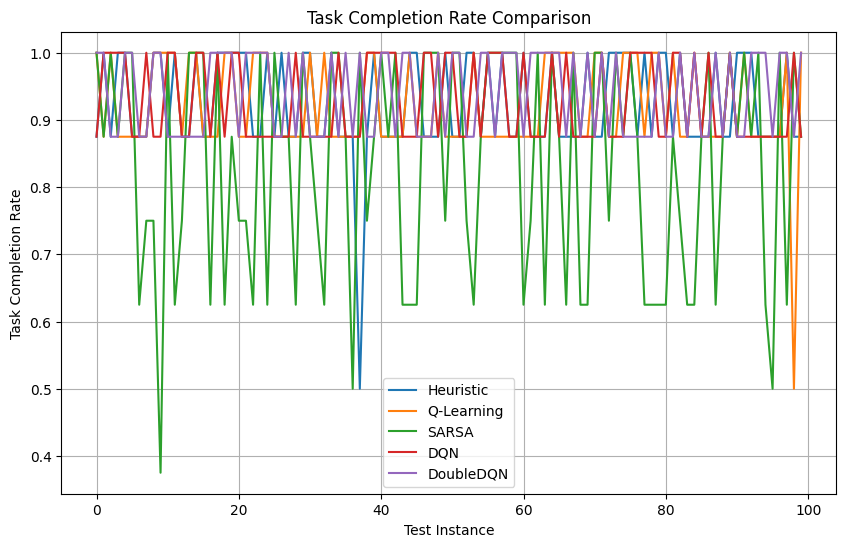

In [37]:
plt.figure(figsize=(10, 6))

for k, v in results.items():
    plt.plot(v["TaskCompletionRate"].values[:100], label=k)

plt.legend()
plt.title("Task Completion Rate Comparison")
plt.xlabel("Test Instance")
plt.ylabel("Task Completion Rate")
plt.grid()
plt.show()

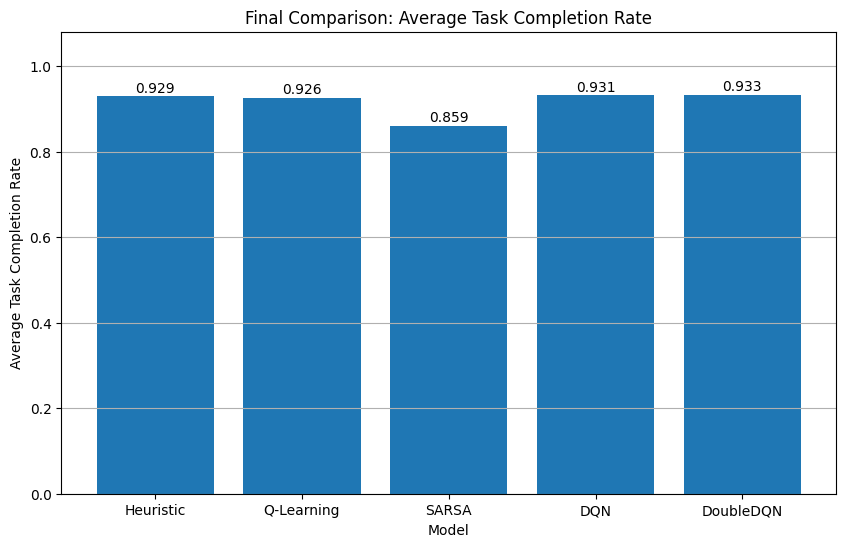

In [43]:
plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df["Model"], summary_df["Avg Task Completion Rate"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.3f}", ha="center")

plt.title("Final Comparison: Average Task Completion Rate")
plt.xlabel("Model")
plt.ylabel("Average Task Completion Rate")
plt.ylim(0, 1.08)
plt.grid(axis="y")
plt.show()

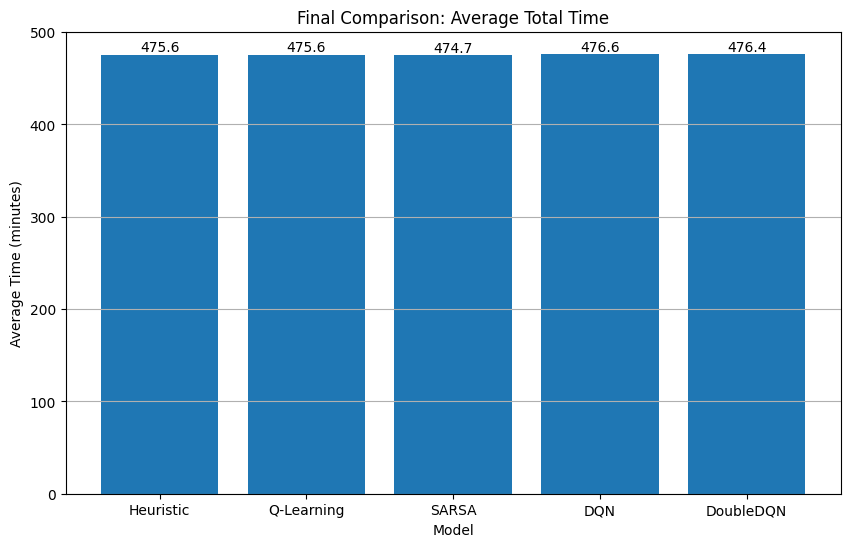

In [44]:
plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df["Model"], summary_df["Avg Time"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 3, f"{y:.1f}", ha="center")

plt.title("Final Comparison: Average Total Time")
plt.xlabel("Model")
plt.ylabel("Average Time (minutes)")
plt.grid(axis="y")
plt.show()

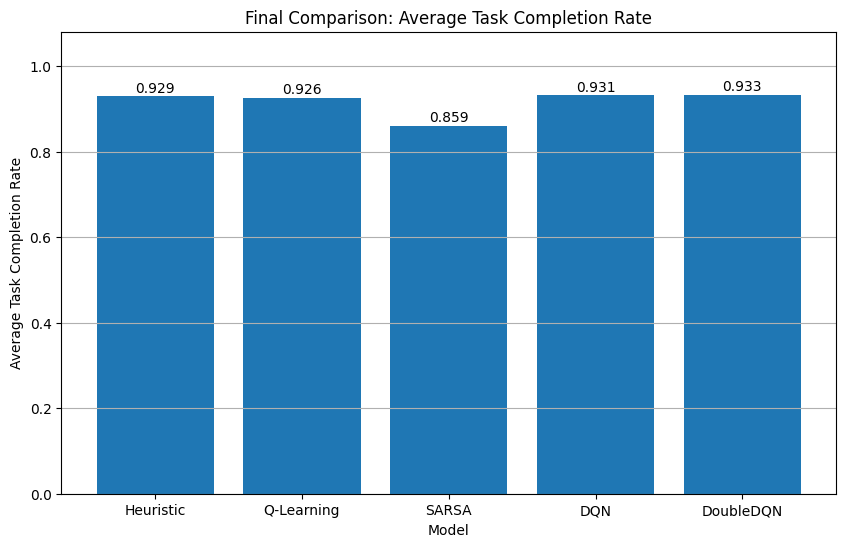

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df["Model"], summary_df["Avg Task Completion Rate"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.3f}", ha="center")

plt.title("Final Comparison: Average Task Completion Rate")
plt.xlabel("Model")
plt.ylabel("Average Task Completion Rate")
plt.ylim(0, 1.08)
plt.grid(axis="y")
plt.show()

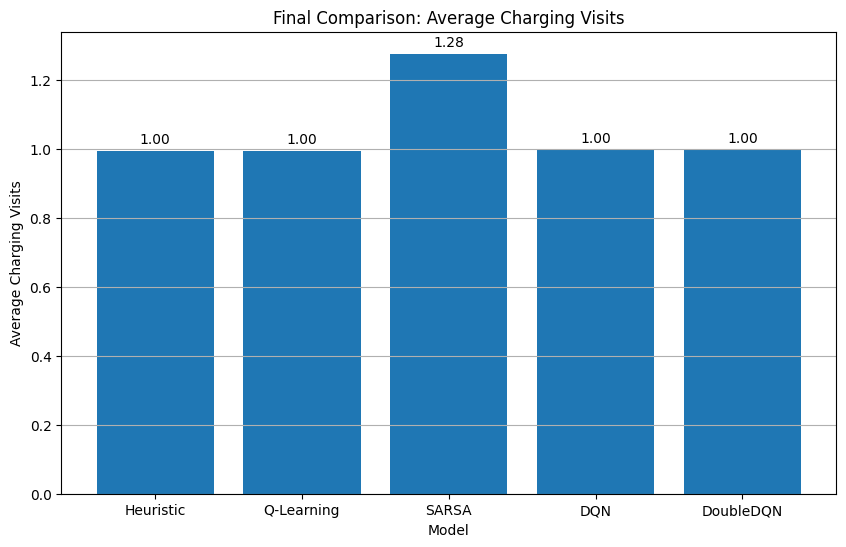

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df["Model"], summary_df["Avg Charges"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.02, f"{y:.2f}", ha="center")

plt.title("Final Comparison: Average Charging Visits")
plt.xlabel("Model")
plt.ylabel("Average Charging Visits")
plt.grid(axis="y")
plt.show()

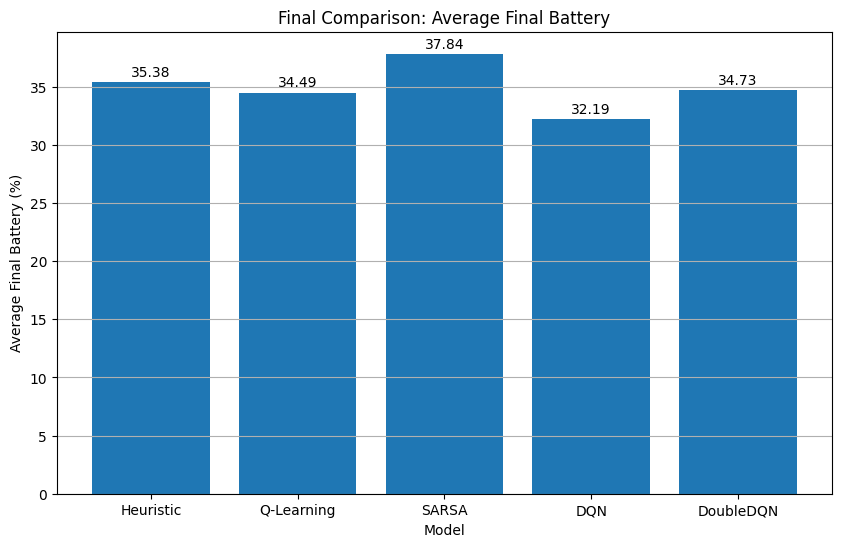

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df["Model"], summary_df["Avg Battery"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.5, f"{y:.2f}", ha="center")

plt.title("Final Comparison: Average Final Battery")
plt.xlabel("Model")
plt.ylabel("Average Final Battery (%)")
plt.grid(axis="y")
plt.show()

In [55]:
final_ranked = summary_df.sort_values(by="Avg Time").reset_index(drop=True)

final_ranked_display = final_ranked[
    ["Model", "Avg Time", "Avg Charges", "Avg Battery", "Avg Task Completion Rate"]
].copy()

final_ranked_display = final_ranked_display.round({
    "Avg Time": 2,
    "Avg Charges": 2,
    "Avg Battery": 2,
    "Avg Task Completion Rate": 3
})

print(final_ranked_display)

final_ranked_display.to_csv("Final_Ranked_Results.csv", index=False)

        Model  Avg Time  Avg Charges  Avg Battery  Avg Task Completion Rate
0       SARSA    474.73         1.28        37.84                     0.859
1   Heuristic    475.56         1.00        35.38                     0.929
2  Q-Learning    475.59         1.00        34.49                     0.926
3   DoubleDQN    476.38         1.00        34.73                     0.933
4         DQN    476.55         1.00        32.19                     0.931


In [56]:
best_model = summary_df.sort_values(by="Avg Time").iloc[0]["Model"]
best_completion = summary_df.loc[summary_df["Model"] == best_model, "Avg Task Completion Rate"].values[0]

print(f"Best model by time efficiency: {best_model}")
print(f"Average task completion rate of the best model: {best_completion:.3f}")
print("Since the models do not all achieve identical completion rates, the final comparison considers both completion performance and operational efficiency metrics.")

Best model by time efficiency: SARSA
Average task completion rate of the best model: 0.859
Since the models do not all achieve identical completion rates, the final comparison considers both completion performance and operational efficiency metrics.
